## Import the necessary functions 

In [1]:
# Import the necessary functions

# Personalised functions created for this NN application
from NEMO_NN_functions import *
# To convert from lat lon, to x y
from pyproj import Transformer
# To extract just the bedmachine mask within the NEMO 1 degree grid 
from shapely.geometry import Polygon
from shapely.vectorized import contains
# To extract neighbouring cells
from scipy.ndimage import binary_dilation 
# To plot figures 
import matplotlib.pyplot as plt

# To create the ocean profile 
from scipy.spatial import cKDTree

## Set variables 

In [2]:
# Set the filepaths 

# NEMO simulation temperature and salinity profiles 
filepath_nemo_output = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/ECM71-ico-LR-pi-01.pi_1883_1Y_grid_T.nc'

# Filepath_bedmachine 
filepath_bedmachine = '../AIAI_data/BedMachineAntarctica-v3.nc'

## Create the mask of ocean coordinates to extract the temperature and salinity profiles 
In this case have to extract the mask and the coordinates at the same time, because some cells share the closest ocean points 

In [3]:
nemo_run = 'OPM016'

# Set the filepaths 
# Where are the masks stored for the target grid?
filepath_base = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/'
# At this stage we need to also have the mask for the target grid 
filepath_mask = filepath_base +  'AIAI_data/Masks/'+nemo_run+'_'+'geometric_masks.nc'
# A geometry file with the required variables for the NN 
filepath_geomvars = filepath_base + 'AIAI_data/Masks/'+nemo_run+'_'+'geom_vars.nc'

# Load in the mask and geometry 
masks, basins_merged, geoms = load_geom_files(filepath_geomvars, filepath_mask, join_ice_shelves = False)

You have loaded: /bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Masks/OPM016_geom_vars.nc
You have loaded: /bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Masks/OPM016_geometric_masks.nc


In [4]:
# Extract the coordinates of all the closed_cavities 
idx = np.where(masks.closed_cavities == 1)
lat_cavs = masks.lat.values[idx]
lon_cavs = masks.lon.values[idx]
basin_cavs = masks.basins_NEMO.values[idx]
# Transform to x and y
transformer = Transformer.from_crs("epsg:4326","epsg:3031")
x_cavs_all, y_cavs_all = transformer.transform(lat_cavs, lon_cavs)

In [5]:
i_not_in_cavs = []
basins_with_cavs = []
for i in range(len(np.unique(masks.basins_NEMO))):
    if np.unique(masks.basins_NEMO)[i] not in np.unique(basin_cavs.astype(int)):
        i_not_in_cavs.append(i)
    else:
        basins_with_cavs.append(i)
print('There are {} basins with no closed cavities: {}'.format(len(i_not_in_cavs), i_not_in_cavs))
print('There are {} basins with cavities: {}'.format(len(basins_with_cavs), basins_with_cavs))

There are 14 basins with no closed cavities: [4, 9, 29, 32, 38, 42, 47, 52, 53, 95, 105, 113, 122, 130]
There are 141 basins with cavities: [0, 1, 2, 3, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 30, 31, 33, 34, 35, 36, 37, 39, 40, 41, 43, 44, 45, 46, 48, 49, 50, 51, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 96, 97, 98, 99, 100, 101, 102, 103, 104, 106, 107, 108, 109, 110, 111, 112, 114, 115, 116, 117, 118, 119, 120, 121, 123, 124, 125, 126, 127, 128, 129, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154]


In [6]:
# Calculate the regions which contain ocean, and either contain entirely ocean and ice shelf or no ice shelf 

In [7]:
# Load in the coordinates for the grid 
coords = load_gridcoords(filepath_nemo_output)
# Load in bedmachine (for the mask layer) 
# Values in the bedmachine mask layer 
# 0 == Ocean
# 1 == Ice free land 
# 2 == Grounded ice 
# 3 == Floating ice 
# 4 == Lake vostok 
bmach3 = xr.open_dataset(filepath_bedmachine)
xbmach,ybmach = np.meshgrid(bmach3.x, bmach3.y)

You have loaded coordinates: /bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/ECM71-ico-LR-pi-01.pi_1883_1Y_grid_T.nc
Cropped to Antarctica only


In [8]:
# For each NEMO cell, calculate the fraction of the cell which is open ocean and ice shelf cavities 
transformer = Transformer.from_crs("epsg:4326","epsg:3031")

save_data = False
if save_data == True:
    fraction_OO = np.ones(coords.nav_lat.shape) * np.nan
    fraction_IC = np.ones(coords.nav_lat.shape) * np.nan
    fraction_GI = np.ones(coords.nav_lat.shape) * np.nan
    fraction_IFL = np.ones(coords.nav_lat.shape) * np.nan
    fraction_LV = np.ones(coords.nav_lat.shape) * np.nan
    for i in range(coords.nav_lat.shape[0]):
        for j in range(coords.nav_lon.shape[1]):
            x_square = []
            y_square = []
            for jkl in (0,1,2,3):
                x2, y2 = transformer.transform(coords.bounds_nav_lat.sel(nvertex = jkl)[i,j].values, \
                                                       coords.bounds_nav_lon.sel(nvertex = jkl)[i,j].values)
                x_square.append(x2)
                y_square.append(y2)
            bounds = [np.min(x_square), np.max(x_square), np.min(y_square), np.max(y_square)]
            # Extract the bedmachine mask within the boundaries of the cell 
            bmach_slice = bmach3.sel(x=slice(bounds[0], bounds[1]), y=slice(bounds[3], bounds[2]))
            if len(bmach_slice.x) == 0:
                a = np.nan
            else:
                # List corners of rotated rectangle and create polygon
                corners = [(x_square[0], y_square[0]), (x_square[1], y_square[1]), \
                           (x_square[2], y_square[2]), (x_square[3], y_square[3])]
                poly = Polygon(corners)
                # Mask of points inside polygon
                X, Y = np.meshgrid(bmach_slice.x.values, bmach_slice.y.values)
                mask = contains(poly, X, Y)
                # Extract bmach_slice inside polygon
                sub_mask = bmach_slice.mask.where(mask == True)
                # Calculate the fraction of points in the mask which are not 100% ocean/cavity
                total_points = np.sum(~np.isnan(sub_mask))
                if total_points > 0:
                    fraction_GI[i,j] = np.sum(sub_mask == 2).values/total_points
                    fraction_IFL[i,j] = np.sum(sub_mask == 1).values/total_points
                    fraction_LV[i,j] = np.sum(sub_mask == 4).values/total_points
                    fraction_OO[i,j] = np.sum(sub_mask == 0).values/total_points
                    fraction_IC[i,j] = np.sum(sub_mask == 3).values/total_points 
        print(i+1, 'out of', coords.nav_lat.shape[0], end = '\r')
    np.savetxt('fraction_IC.csv', fraction_IC)
    np.savetxt('fraction_OO.csv', fraction_OO)
    np.savetxt('fraction_GI.csv', fraction_GI)
    np.savetxt('fraction_IFL.csv', fraction_IFL)
    np.savetxt('fraction_LV.csv', fraction_LV)
else:
    fraction_IC = np.loadtxt('fraction_IC.csv')
    fraction_OO = np.loadtxt('fraction_OO.csv')
    fraction_GI = np.loadtxt('fraction_GI.csv')
    fraction_IFL = np.loadtxt('fraction_IFL.csv')
    fraction_LV = np.loadtxt('fraction_LV.csv')

In [9]:
# Create a mask with all the points which are 100% open ocean or cavity 
fraction_GI[np.isnan(fraction_GI)] = 0
fraction_IFL[np.isnan(fraction_IFL)] = 0
fraction_LV[np.isnan(fraction_LV)] = 0
fraction_OO[np.isnan(fraction_OO)] = 0
fraction_IC[np.isnan(fraction_IC)] = 0

# Regions which are fully ocean or ice shelf (so left to be resolved in the model)
mask_OOIC = fraction_OO+fraction_IC
# Regions which are fully ocean or grounded ice 
mask_OOGI = fraction_OO+fraction_GI+fraction_IFL+fraction_LV

# Sometimes there are really tiny bits of ice shelf and these make the mask a bit silly, so we can remove these 
# Set to 0 if you want to keep everything
fraction_of_edge = 0.0001

# Create a mask 
# 0 ignore these cells
# 1 Fully grounded 
# 2 Contains partial cavities
# 3 Ocean or complete cavity cells
mask_closedcavities = mask_OOIC.copy()
mask_closedcavities[mask_closedcavities > -1] = 0
mask_closedcavities[mask_OOIC > (1-fraction_of_edge)] = 3
mask_closedcavities[mask_OOGI > (1-fraction_of_edge)] = 1
mask_closedcavities[fraction_OO == 1] = 3
mask_closedcavities[(mask_OOIC < (1-fraction_of_edge)) & (mask_OOIC > (0+fraction_of_edge)) & \
                    (mask_OOGI > (0+fraction_of_edge)) & (mask_OOGI < (1-fraction_of_edge))] = 2

plot = False
if plot == True:
    plt.pcolor(mask_closedcavities, cmap = 'Blues')
    plt.colorbar()

In [10]:
# Create a mask with all the points that contain ocean but not ice shelf 
mask_nocavs = mask_OOGI.copy()
mask_nocavs[fraction_OO == 0] = 0
mask_nocavs[mask_nocavs < 1] = 0
# Include regions which are fully ice shelf and ocean 
mask_nocavs[mask_OOIC == 1] = 1

In [11]:
# Regions where it is acceptable to extract ocean profiles 
iy, ix = np.where(mask_nocavs == 1)
# coordinates of those cells
lat_ocean = coords.nav_lat.values[iy, ix]
lon_ocean = coords.nav_lon.values[iy, ix]
# Transform to x and y
transformer = Transformer.from_crs("epsg:4326","epsg:3031")
x_ocean, y_ocean = transformer.transform(lat_ocean, lon_ocean)
# Stack to prepare for the KDTree
ocean_points = np.column_stack((x_ocean, y_ocean))
# Create KDTree
tree = cKDTree(ocean_points)
# Stack cavity points to query KDTree
cav_points = np.column_stack((x_cavs_all, y_cavs_all))
dist, idx = tree.query(cav_points)
# Create a new array for the ocean edge points
# Same dimensions as the mask of the not cavities
ocean_edge = np.zeros_like(mask_nocavs)
# And fill the cells found with the kd-tree
for k in range(len(idx)):
    ocean_edge[iy[idx[k]], ix[idx[k]]] = 1

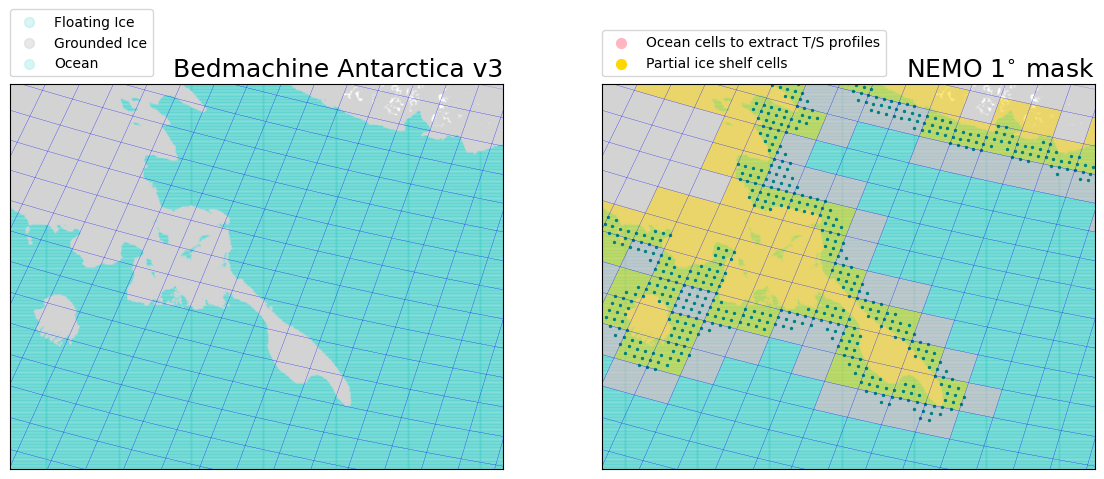

In [12]:
plot_mask = True
if plot_mask == True:
    fig, ax = plt.subplots(1,2, figsize = (14,5))
    
    plotting_area = 'Ross' # 'Thwaites''Ross'
    if plotting_area == 'Thwaites':
        i_low, i_high, j_low, j_high = 45, 65, 170, 190
        xlims = (-1.83e6,-1.48e6)
        ylims = (-0.65e6,-0.25e6)
    elif plotting_area == 'Ross':
        i_low, i_high, j_low, j_high = 6, 23, 11, 130
        xlims = (-0.250e6,-0.0e6)
        ylims = (-0.825e6, -0.575e6)

    for i in range(i_low, i_high):
        for j in range(j_low, j_high):
            x_square = []
            y_square = []
            for jkl in (0,1,2,3):
                x2, y2 = transformer.transform(coords.bounds_nav_lat.sel(nvertex = jkl)[i,j].values, \
                                                       coords.bounds_nav_lon.sel(nvertex = jkl)[i,j].values)
                x_square.append(x2)
                y_square.append(y2)
            corners = [(x_square[0], y_square[0]), (x_square[1], y_square[1]), \
                               (x_square[2], y_square[2]), (x_square[3], y_square[3])]
            x_corner = (x_square[0], x_square[1], x_square[2], x_square[3], x_square[0])
            y_corner = (y_square[0], y_square[1], y_square[2], y_square[3], y_square[0])
            poly = Polygon(corners)
            ax[0].plot(x_corner, y_corner, c = 'blue', linewidth = 0.1)
            ax[1].plot(x_corner, y_corner, c = 'blue', linewidth = 0.1)
            if ocean_edge[i,j] == 1:
                im = ax[1].fill(x_corner, y_corner, alpha = 0.5, c = 'lightpink', edgecolor = 'None', zorder = 1)
            if mask_closedcavities[i,j] == 2:
                im = ax[1].fill(x_corner, y_corner, alpha = 0.5, c = 'gold', edgecolor = 'None', zorder = 1)

    ax[1].scatter(0,0, color = 'lightpink', s = 0.5, label = 'Ocean cells to extract T/S profiles')
    ax[1].scatter(0,0, color = 'gold', s = 0.5, label = 'Partial ice shelf cells')

    #x3, y3 = transformer.transform(masks.lat.values[masks.closed_cavities_nan.values == 1], \
    #                                                   masks.lon.values[masks.closed_cavities_nan.values == 1])
    #ax[1].scatter(x3,y3, s = 2, c = 'teal')
    
    label = 'Bedmachine Antarctica v3', 'NEMO 1$^{\\circ}$ mask'
    label2 = 'Grounded Ice', ''
    label3 = 'Floating Ice', ''
    for i in range(2):
        ax[i].set_xlim(xlims)
        ax[i].set_ylim(ylims)
        ax[i].set_xticks([]);
        ax[i].set_yticks([]);
        value = 3
        ax[i].scatter(xbmach[bmach3.mask == value], ybmach[bmach3.mask == value], s = 0.5, c = 'mediumturquoise', \
                  label = label3[i], zorder = 0, alpha = 0.2)
        value = 2
        ax[i].scatter(xbmach[bmach3.mask == value], ybmach[bmach3.mask == value], s = 0.5, c = 'lightgrey', \
                  label = label2[i], zorder = 0, alpha = 0.5)
        ax[i].annotate(label[i], xy = (0,0), xytext = (1.0,1.02), ha = 'right', xycoords = 'axes fraction', fontsize = 18)
        value = 0
        ax[0].scatter(xbmach[bmach3.mask == value], ybmach[bmach3.mask == value], s = 0.5, c = 'paleturquoise', \
                  label = 'Ocean', zorder = 0, alpha = 0.5)
        ax[i].legend(loc = (0,1.02), markerscale = 10);

#fig.savefig('Mask_method.jpg', bbox_inches = 'tight', dpi = 200)

## Extract the temperature and salinity profiles 

In [13]:
np.sum(masks.basins_NEMO.values- basins_merged)

<xarray.DataArray 'basins_NEMO' ()>
array(0., dtype=float32)

In [14]:
# Load in the basins file for 025
# Edit for NEMO 1

ds0=xr.open_dataset('../MASKS_PARAM/basin_raster_extrapolate_eANT025.nc')
basins_NEMO = ds0.basin.values
ds0.close()

#filepath_basins_1 = '../MASKS_PARAM/basin_raster_NEMO1.nc'
#ds_basin = xr.open_dataset(filepath_basins_1)
#basins_NEMO = ds_basin.Basins_NEMO_1degree.values
#ds_basin.close()

# Some ice shelves which should potentially be joined together into one bigger ice shelf
join_ice_shelves = True
if join_ice_shelves == True:
    # Dotson and Crosson?
    #basins_NEMO[basins_NEMO == 101] = 129
    # Abbot Ice Shelf
    basins_NEMO[basins_NEMO == 109] = 143
    # George VI
    basins_NEMO[basins_NEMO == 112] = 125
    # Lambert 
    basins_NEMO[basins_NEMO == 20] = 103
#basin_nos = np.unique(basins_NEMO)
basin_nos = np.arange(1,156, dtype = 'float32')

# Regions where it is acceptable to extract ocean profiles 
iy, ix = np.where((mask_nocavs == 1))
# coordinates of those cells
lat_ocean = coords.nav_lat.values[iy, ix]
lon_ocean = coords.nav_lon.values[iy, ix]
# Transform to x and y
transformer = Transformer.from_crs("epsg:4326","epsg:3031")
x_ocean, y_ocean = transformer.transform(lat_ocean, lon_ocean)
# Stack to prepare for the KDTree
ocean_points = np.column_stack((x_ocean, y_ocean))
# Create KDTree
tree = cKDTree(ocean_points)

# Load in the TS grid 
gridT2 = load_TSmelt_normal(filepath_nemo_output)

You have loaded T and S: /bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/ECM71-ico-LR-pi-01.pi_1883_1Y_grid_T.nc
Cropped to Antarctica only


In [15]:
# For each basin in basin_nos, create a mask of the ocean profiles to extract 
profiles_all = []
i_no_value = []
basins_all_temp = np.zeros_like(mask_nocavs)
for kk in range(len(basin_nos)):
    i = basin_nos[kk]
    mask_basin_cavs = (basins_NEMO == i) & (masks.closed_cavities == 1)
    # Extract these points 
    idx = np.where(mask_basin_cavs == 1)
    lat_cavs = masks.lat.values[idx]
    lon_cavs = masks.lon.values[idx]
    # Transform to x and y
    transformer = Transformer.from_crs("epsg:4326","epsg:3031")
    x_cavs, y_cavs = transformer.transform(lat_cavs, lon_cavs)
    # Stack cavity points to query KDTree
    cav_points = np.column_stack((x_cavs, y_cavs))
    dist, idx = tree.query(cav_points)
    # Same dimensions as the mask of the not cavities
    ocean_edge_basin = np.zeros_like(mask_nocavs)
    # And fill the cells found with the kd-tree
    for k in range(len(idx)):
        ocean_edge_basin[iy[idx[k]], ix[idx[k]]] = 1
        
    # Calculate which basins don't have profiles 
    if np.sum(ocean_edge_basin) == 0:
        i_no_value.append(int(i))
    ### This is only needed if you want to look at which ocean cells will recieve melt from many basins   
    basins_all_temp = basins_all_temp + ocean_edge_basin
   
    # Use the mask to extract the relevant profiles 

    masked_depth = gridT2.where(ocean_edge_basin == 1)
    profiles = masked_depth.stack(points=("x", "y"))
    profiles = profiles.dropna(dim="points", how="all")
    profiles = profiles.drop_vars(["area", "bathy", "isf_draft"]) 
    # Fill the nan values in the profile
    profile_kk = profiles.mean(dim = 'points').interpolate_na(dim = 'deptht').ffill('deptht').bfill('deptht')
    # Add a coordinate for kk
    profile_kk = profile_kk.expand_dims(kk =[int(i)])
    #profile_kk = profile_kk.expand_dims(kk_m1 =[int(i)-1])
    profiles_all.append(profile_kk)
    print('{} out of {} profiles processed'.format(kk+1, len(basin_nos)), end = '\r')
# Concatenate the profiles along the new dimension
all_profiles = xr.concat(profiles_all, dim="kk")

print('There are {} basins with no ocean profiles : {}'.format(len(i_no_value), i_no_value))
print('There should be 17 basins (14 with no cavities plus 3 where we merged)')

There are 17 basins with no ocean profiles : [5, 10, 20, 30, 33, 39, 43, 48, 53, 54, 96, 106, 109, 112, 114, 123, 131]
There should be 17 basins (14 with no cavities plus 3 where we merged)


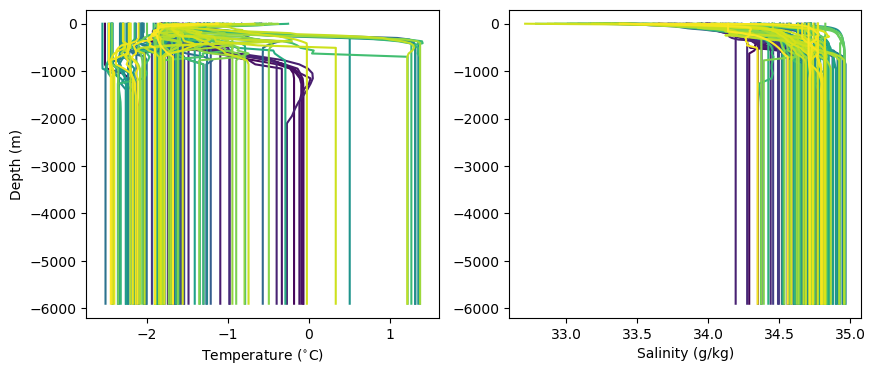

In [16]:
plot_profile = True
if plot_profile == True:
    fig, ax = plt.subplots(1,2, figsize = (10,4))
    for kk in all_profiles.kk.values:
        profile = all_profiles.sel(kk=kk)
        ax[0].plot(profile.thetao, -profile.deptht, c = plt.cm.viridis(kk/np.max(all_profiles.kk.values)))
        ax[1].plot(profile.so, -profile.deptht, c = plt.cm.viridis(kk/np.max(all_profiles.kk.values)))
    ax[0].set_ylabel('Depth (m)');
    #ax[1].set_ylabel('Depth (m)')
    ax[0].set_xlabel('Temperature ($^{\\circ}$C)');
    ax[1].set_xlabel('Salinity (g/kg)');

## Propagate the temperature and salinity profiles onto the target grid 

In [17]:
## Propagate the temperature and salinity profiles onto the target grid 

# Load in the target grid 

nemo_run = 'OPM016'

# Where are the masks stored for the target grid?
filepath_base = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/'
# Where do you want processed files to be stored? 
filepath_nn_input = filepath_base + "data/processing_ho/nn_input_"

# Set the filepaths 
# At this stage we need to also have the mask for the target grid 
filepath_mask = filepath_base +  'AIAI_data/Masks/'+nemo_run+'_'+'geometric_masks.nc'
# A geometry file with the required variables for the NN 
filepath_geomvars = filepath_base + 'AIAI_data/Masks/'+nemo_run+'_'+'geom_vars.nc'

# Load in the mask and geometry 
masks, basins_merged, geoms = load_geom_files(filepath_geomvars, filepath_mask, join_ice_shelves = join_ice_shelves)
# We have all the profiles, as a function of kk, and deptht
# all_profiles.thetao
# We have the basins as a function of x_grid and y_grid 
# basins_merged
# which we rename the dimensions to be x and y 
basins_merged = basins_merged.rename({"y_grid_T": "y", "x_grid_T": "x"}).astype(int)
# and we have the ice draft depth as a function of x and y 
# geoms.isf_draft

You have loaded: /bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Masks/OPM016_geom_vars.nc
You have loaded: /bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Masks/OPM016_geometric_masks.nc
Ice shelves joined, as requested


In [18]:
# Extract the relevant values of temperature and salinity 
temp_xy = all_profiles.thetao.interp(deptht = geoms.isf_draft).sel(kk=basins_merged)
sals_xy = all_profiles.so.interp(deptht = geoms.isf_draft).sel(kk=basins_merged)

In [19]:
# Convert to float to avoid errors from nans
#temp_xy = temp_xy.astype(float)
#sals_xy = sals_xy.astype(float)
#basins_merged = basins_merged.astype(float)
# Calculate mean and standard deviation by region
# Note: this step produces an error because some basins have nan mean, but the code still runs so it's okay?
meanT_by_region = temp_xy.groupby(basins_merged).mean()
stdT_by_region  = temp_xy.groupby(basins_merged).std()
meanS_by_region = sals_xy.groupby(basins_merged).mean()
stdS_by_region  = sals_xy.groupby(basins_merged).std()
# and send back to the original grid 
mean_T = meanT_by_region.sel(basins_NEMO = basins_merged)
std_T = stdT_by_region.sel(basins_NEMO = basins_merged)
mean_S = meanS_by_region.sel(basins_NEMO = basins_merged)
std_S = stdS_by_region.sel(basins_NEMO = basins_merged)

/home/ockendeh/miniconda3/envs/nnets_py38/lib/python3.12/site-packages/numpy/core/numeric.py:407: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')
/home/ockendeh/miniconda3/envs/nnets_py38/lib/python3.12/site-packages/numpy/core/numeric.py:407: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')
/home/ockendeh/miniconda3/envs/nnets_py38/lib/python3.12/site-packages/numpy/core/numeric.py:407: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')
/home/ockendeh/miniconda3/envs/nnets_py38/lib/python3.12/site-packages/numpy/core/numeric.py:407: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')


/tmp/ipykernel_836609/3097248495.py:13: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cbar = plt.colorbar(im[i], ax = ax[i], orientation = 'horizontal', pad = 0.01, shrink = 0.5)


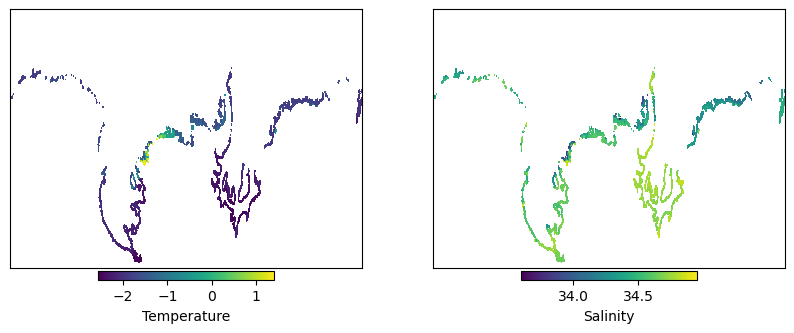

In [20]:
plot_figure = True
if plot_figure == True:
    fig, ax = plt.subplots(1,2, figsize = (10,4))
    closed_cavs = masks.closed_cavities_nan.rename({"y_grid_T": "y", "x_grid_T": "x"})
    im = [[],[]]
    # Note that using pcolor rather than pcolormesh leads to the error
    im[0] = ax[0].pcolor(temp_xy*closed_cavs)
    im[1] = ax[1].pcolor(sals_xy*closed_cavs)
    labels = 'Temperature', 'Salinity'
    for i in range(2):
        ax[i].set_xticks([])
        ax[i].set_yticks([])
        cbar = plt.colorbar(im[i], ax = ax[i], orientation = 'horizontal', pad = 0.01, shrink = 0.5)
        cbar.set_label(labels[i])

In [21]:
simulation = 'DUM001'
year_of_interest = '9999'
# Create a netcdf dataset for the temperature and salinity profiles 
ds = xr.Dataset(data_vars=dict(
                                temperature_prop = (["y", "x"], temp_xy.data),
                                salinity_prop    = (["y", "x"], sals_xy.data), 
                              ),
                   coords=dict(
                               lon = (("y", "x"), geoms.lon.data),
                               lat = (("y", "x"), geoms.lat.data),    
                              ),
                    attrs=dict(
                               description    = "Neural network input variables", 
                               simulation_run = simulation, 
                               year           = year_of_interest),
                              )
# Export to netcdf 
ds.to_netcdf(filepath_nn_input + simulation + '_' + year_of_interest + '.nc')

## Prepare the data to apply the neural network 

In [22]:
# Create the input dataset for the neural network to be applied to
ds = xr.Dataset(data_vars=dict(
                               distances_GL           = (["y", "x"], geoms.distances_GL.data),
                               distances_OO           = (["y", "x"], geoms.distances_OO.data),
                               distances_OC           = (["y", "x"], geoms.distances_OC.data),
                               area                   = (["y", "x"], geoms.areas.data),
                               temperature_prop       = (["y", "x"], temp_xy.data),
                               mean_T                 = (["y", "x"], mean_T.data),
                               std_T                  = (["y", "x"], std_T.data),
                               salinity_prop          = (["y", "x"], sals_xy.data), 
                               mean_S                 = (["y", "x"], mean_S.data),
                               std_S                  = (["y", "x"], std_S.data),
                               corrected_isdraft      = (["y", "x"], geoms.isf_draft.data),
                               bathymetry             = (["y", "x"], geoms.bathymetry.data),
                               slope_is_lon           = (["y", "x"], geoms.slope_isdraft_lon.data),
                               slope_is_lat           = (["y", "x"], geoms.slope_isdraft_lat.data), 
                               slope_ba_lon           = (["y", "x"], geoms.slope_bathy_lon.data),
                               slope_ba_lat           = (["y", "x"], geoms.slope_bathy_lat.data),
                               slope_is_across_front  = (["y", "x"], geoms.slope_is_across_front.data),
                               slope_is_towards_front = (["y", "x"], geoms.slope_is_towards_front.data), 
                               slope_ba_across_front  = (["y", "x"], geoms.slope_ba_across_front.data),
                               slope_ba_towards_front = (["y", "x"], geoms.slope_ba_towards_front.data),
                               basins_NEMO            = (["y", "x"], basins_merged.data),
                              ),
                   coords=dict(
                               lon = (("y", "x"), geoms.lon.data),
                               lat = (("y", "x"), geoms.lat.data),    
                              ),
                    attrs=dict(
                               description    = "Neural network input variables", 
                               simulation_run = simulation, 
                               year           = year_of_interest),
                              )

**Note: You might want to redo the closed cavities mask to correspond better to the NEMO 1 degree grid, but for now sticking with the grid from Nico**

In [23]:
# Rename variables in closed cavity mask 
closed_cavs = masks.closed_cavities_nan.rename({"y_grid_T": "y", "x_grid_T": "x"})

# Select only the points in the closed cavity regions
selected = ds.where(closed_cavs == 1).stack(points=("x", "y"))#.dropna("points")
# and convert to a pandas dataframe
selected = selected.reset_coords(drop=False).to_dataframe().reset_index(drop=True).drop(columns=["x", "y"])
# Remove nan values (although still unclear why there are nan values)
selected = selected[~np.isnan(selected.temperature_prop)]

# Which neural network have you chosen?
this_collection = 'OPM026_OPM0263_OPM031_OPM016_OPM018_OPM021_ctrl94_isf94_isfru94'
exp_name = 'slope_front'

# Where is the neural network stored?
path_model = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/NN_models/'
path_norm_metrics = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Training_data/'

# Apply all 10 neural networks 
melt_by_basin = apply_10nns(exp_name, this_collection, selected.to_xarray(), path_model, path_norm_metrics)

## Redistribute melt onto the ocean_edge grid

In [24]:
melt_all = np.zeros_like(mask_nocavs)
for kk in range(len(melt_by_basin.basin)):
    i = melt_by_basin.basin[kk]
    mask_basin_cavs = (basins_NEMO == i) & (masks.closed_cavities == 1)
    # Extract these points 
    idx = np.where(mask_basin_cavs == 1)
    lat_cavs = masks.lat.values[idx]
    lon_cavs = masks.lon.values[idx]
    # Transform to x and y
    transformer = Transformer.from_crs("epsg:4326","epsg:3031")
    x_cavs, y_cavs = transformer.transform(lat_cavs, lon_cavs)
    # Stack cavity points to query KDTree
    cav_points = np.column_stack((x_cavs, y_cavs))
    dist, idx = tree.query(cav_points)
    # Same dimensions as the mask of the not cavities
    ocean_edge_basin = np.zeros_like(mask_nocavs)
    # And fill the cells found with the kd-tree
    for k in range(len(idx)):
        ocean_edge_basin[iy[idx[k]], ix[idx[k]]] = 1
    # Redistribute the melt over the relevant cells
    pixels = np.sum(ocean_edge_basin)
    melt_per_pixel = melt_by_basin.melt_Gt[kk]/pixels
    ocean_melt = ocean_edge_basin * melt_per_pixel
    # Sum up the melt over all the basins
    melt_all = melt_all + ocean_melt

In [25]:
filepath_nn_output = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/data/processing_ho/'

In [26]:
# Create a netcdf dataset for the temperature and salinity profiles 
output_melt = xr.Dataset(data_vars=dict(
                                melt = (["y", "x"], melt_all.data), 
                              ),
                   coords=dict(
                               lon = (("y", "x"), coords.nav_lon.data),
                               lat = (("y", "x"), coords.nav_lat.data),    
                              ),
                    attrs=dict(
                               description    = "Neural network input variables", 
                               simulation_run = simulation, 
                               year           = year_of_interest),
                              )
# Export to netcdf 
output_melt.to_netcdf(filepath_nn_output + 'nn_output_melt' '_' + simulation + '_' + year_of_interest + '.nc')

## Look at the resulting melt distribution map for NEMO

/tmp/ipykernel_836609/1657122247.py:4: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar(im, ax= ax, pad = 0)
/tmp/ipykernel_836609/1657122247.py:5: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  im.set_clim(-0.1,0)


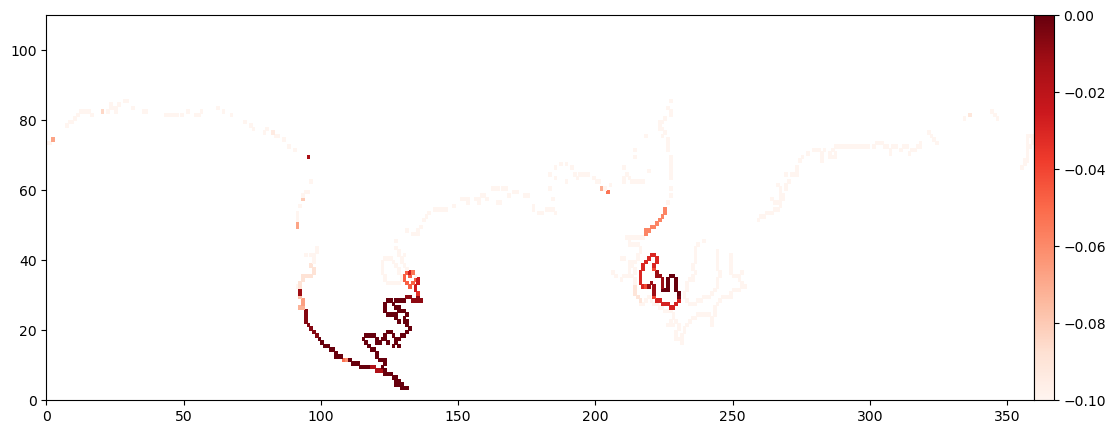

In [27]:
fig, ax = plt.subplots(1,1, figsize = (15,5))
melt_all[melt_all == 0] = np.nan
im = plt.pcolor(melt_all, cmap = 'Reds')
plt.colorbar(im, ax= ax, pad = 0)
im.set_clim(-0.1,0)

# Additional section not for inclusion in final python script

### Creating a better version of the basins map for the NEMO 1 degree grid 

In [28]:
from scipy.spatial import cKDTree
import numpy as np

transformer = Transformer.from_crs("epsg:4326","epsg:3031")
x, y = transformer.transform(coords.nav_lat, coords.nav_lon)
x2,y2 = transformer.transform(masks.lat, masks.lon)

# Build KD-tree on source grid
tree = cKDTree(np.column_stack((x2.ravel(), y2.ravel())))
# Query nearest neighbours for target grid
dist, idx = tree.query(np.column_stack((x.ravel(), y.ravel())))
# Map basins

ds0=xr.open_dataset('../MASKS_PARAM/basin_raster_extrapolate_eANT025.nc')
#basins_NEMO = ds0.basin[::4,::4].values
basins_interp = ds0.basin.data.ravel()[idx].reshape(x.shape)
ds0.close()

# Save the basins array as a .nc 
basins_1 = xr.DataArray(basins_interp,
                        dims = ("y", "x"),
                        coords = {"lat": (("y", "x"), gridT2.nav_lat.data),
                                "lon": (("y", "x"), gridT2.nav_lon.data),},
                        name = "Basins_NEMO_1degree"
                       )
filepath_basins_1 = '../MASKS_PARAM/basin_raster_NEMO1.nc'
basins_1.to_netcdf(filepath_basins_1)

### Which cells recieve melt from more than one basin?

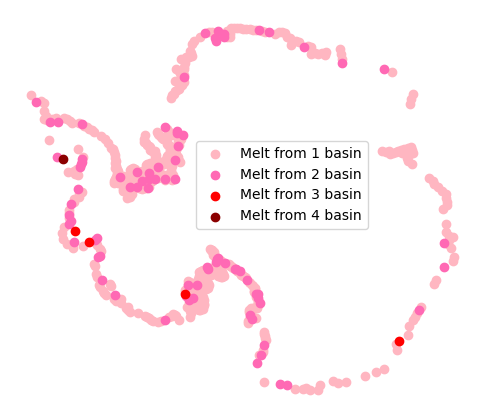

In [34]:
fig, ax = plt.subplots(1,1, figsize = (6,6))
colors = 'lightpink', 'hotpink', 'red', 'darkred'
for i in range(4):
    mask_over = (basins_all_temp == i+1)
    idx = np.where(mask_over == 1)
    lat_over = coords.nav_lat.values[idx]
    lon_over = coords.nav_lon.values[idx]
    transformer = Transformer.from_crs("epsg:4326","epsg:3031")
    x_over, y_over = transformer.transform(lat_over, lon_over)
    plt.scatter(x_over, y_over, color = colors[i], label = 'Melt from {} basin'.format(i+1))
    ax.legend(loc = (0.4,0.45))
    ax.set_aspect('equal', adjustable='box')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.axis('off')
fig.savefig('Multiplebasins.jpg', dpi = 200, bbox_inches = 'tight')